In [ ]:
#!/usr/bin/env python3
#### BINARY (FLOOD OCCURRENCE) VERSION - for binomial GWR on the FULL hex sample


from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from libpysal.weights import Queen
from esda.moran import Moran

# Setup
RESPONSE = "s1"                       # "s1" or "sepa"
HEX_PATH = Path("hex_h3_res9_joined.gpkg")
TARGET_CRS = "EPSG:3035"

RESP_RAW  = {"s1": "s1_flood_frac", "sepa": "sepa_flood_frac"}[RESPONSE]
Y_BINARY  = f"{RESPONSE}_flooded"       # 0/1 occurrence indicator built below
OUT_GPKG  = Path(f"hex_binary_{RESPONSE}.gpkg")
OUT_RPT   = Path(f"cleaning_report_binary_{RESPONSE}.txt")
OUT_PREDS = Path(f"hex_binary_{RESPONSE}_predictors.json")

BW_MIN = 1500  # start here; raise further if separation persists

# Transform decisions (from the transformation-summary table).
SQRT_VARS = ["pop_density", "building_footprint_frac", "impervious_pct", "mean_slope", "dist_to_river_m"]

# Predictor set fed to VIF / model, using the transformed names.
PREDICTORS = [
    "sqrt_pop_density",
    "sqrt_building_footprint_frac",
    "simd_rank",
    "age_dep_ratio",
    "greenspace_frac",
    "sewer_catchment_coverage",
    "sqrt_impervious_pct",
    "sqrt_mean_slope",
    "sqrt_dist_to_river_m",
]

VIF_THRESHOLD = 10.0

rpt = []
def log(m=""):
    print(m)
    rpt.append(str(m))

# Load
log("=" * 70)
log(f"BINARY CLEANING PIPELINE - response = {RESPONSE}_flooded (from {RESP_RAW})")
log("=" * 70)

gdf = gpd.read_file(HEX_PATH)
log(f"Loaded {len(gdf):,} hexes from {HEX_PATH}")
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs(TARGET_CRS)
    log(f"Reprojected to {TARGET_CRS}")

if RESP_RAW not in gdf.columns:
    raise KeyError(f"Response '{RESP_RAW}' not in file. Columns: {list(gdf.columns)}")

# Build predictors transformations (sqrt where decided; raw kept as it is)
log("\n--- Transforms ---")
for v in SQRT_VARS:
    if v not in gdf.columns:
        raise KeyError(f"Raw predictor '{v}' missing; cannot build sqrt_{v}.")
    if (gdf[v] < 0).any():
        raise ValueError(f"{v} has negative values; sqrt undefined.")
    gdf[f"sqrt_{v}"] = np.sqrt(gdf[v])
    log(f"  sqrt_{v} built")
missing_pred = [c for c in PREDICTORS if c not in gdf.columns]
if missing_pred:
    raise KeyError(f"Predictors missing after transform: {missing_pred}")

# Build binary response (keep all hexes - no zero-drop, no log)
#     flooded = 1 where any flood fraction is recorded, else 0.
log("\n--- Build binary response (full sample kept) ---")
gdf[Y_BINARY] = (gdf[RESP_RAW] > 0).astype(int)
n_pos = int(gdf[Y_BINARY].sum())
n_all = len(gdf)
log(f"  {Y_BINARY}: {n_pos:,} flooded / {n_all:,} total "
    f"({100 * n_pos / n_all:.1f}% positive)")
if n_pos / n_all < 0.05:
    log("  [warning] <5% positive: expect local separation in small GWR windows; "
        "a larger bw_min may be needed.")
if n_pos / n_all > 0.95:
    log("  [warning] >95% positive: negative class is rare; same separation risk inverted.")

# Strucutral missing imputation (sample dense) 
#     age_dep_ratio is NaN on unpopulated hexes (dependents/working-age = 0/0).
#     Structural, not random. 

if "age_dep_ratio" in gdf.columns:
    n_missing = int(gdf["age_dep_ratio"].isna().sum())
    med = gdf["age_dep_ratio"].median()
    gdf["no_population"] = gdf["age_dep_ratio"].isna().astype(int)
    gdf["age_dep_ratio"] = gdf["age_dep_ratio"].fillna(med)
    log("\n--- Structural-missing imputation ---")
    log(f"  age_dep_ratio: {n_missing:,} NaN (unpopulated hexes) -> median {med:.3f}")
    log(f"  added 'no_population' flag ({gdf['no_population'].sum():,} hexes)")

# Distribution audit  (predictors; binary Y audited as a rate)
log("\n--- Distribution audit (full modelling sample) ---")
log(f"  {'variable':<28}{'mean':>10}{'sd':>10}{'skew':>8}{'kurt':>8}")
for c in PREDICTORS:
    v = gdf[c].dropna()
    log(f"  {c:<28}{v.mean():>10.3f}{v.std():>10.3f}"
        f"{stats.skew(v):>8.2f}{stats.kurtosis(v):>8.2f}")

# Listwise NaN DROP   (Y + predictors; GWR cannot take NaN)
need = [Y_BINARY] + PREDICTORS
n1 = len(gdf)
gdf = gdf.dropna(subset=need).copy()
log("\n--- Listwise NaN drop ---")
log(f"  {n1:,} -> {len(gdf):,}  (removed {n1 - len(gdf):,})")
log(f"  MODELLING SAMPLE: {len(gdf):,} hexes")
# re-report class balance after the drop (it can shift)
n_pos = int(gdf[Y_BINARY].sum())
log(f"  post-drop class balance: {n_pos:,} flooded "
    f"({100 * n_pos / len(gdf):.1f}% positive)")
if len(gdf) < 50:
    log("  [warning] very small sample; local fits may be unstable.")

#  VIF   (on the modelling subset; drop > threshold iteratively)
log(f"\n--- VIF (threshold {VIF_THRESHOLD}) ---")
PREDICTORS_FINAL = PREDICTORS.copy()
while True:
    Xv = sm.add_constant(gdf[PREDICTORS_FINAL])
    vif = pd.DataFrame({
        "variable": Xv.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
    })
    vif = vif[vif["variable"] != "const"].sort_values("VIF", ascending=False)
    worst = vif.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD or len(PREDICTORS_FINAL) <= 2:
        break
    PREDICTORS_FINAL.remove(worst["variable"])
    log(f"  dropped {worst['variable']} (VIF {worst['VIF']:.1f})")
log("  final VIF:")
for _, r in vif.iterrows():
    log(f"    {r['variable']:<28}{r['VIF']:>7.2f}")
log(f"  PREDICTORS_FINAL ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")

# Standardise  (X only, on the modelling subset -> _z). y stays 0/1.
log("\n--- Standardise predictors (z-score on modelling subset) ---")
means = gdf[PREDICTORS_FINAL].mean()
sds   = gdf[PREDICTORS_FINAL].std(ddof=0).replace(0, 1.0)
for c in PREDICTORS_FINAL:
    gdf[f"{c}_z"] = (gdf[c] - means[c]) / sds[c]
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
log(f"  standardised: {Z_COLS}")
log("  [note] y is left as raw 0/1 for the Binomial family; do NOT z-score it.")

# Gloabl Logit benchmark and residual RESIDUAL MORAN'S I  (justifies GWR)
#     Binary response -> global logistic regression, not OLS.
log("\n--- Global logit benchmark + residual spatial autocorrelation ---")
Xo = sm.add_constant(gdf[Z_COLS])
try:
    logit = sm.Logit(gdf[Y_BINARY].values, Xo.values).fit(disp=0)
    log(f"  Logit pseudo-R2 {logit.prsquared:.3f}  AIC {logit.aic:.1f}  "
        f"converged={logit.mle_retvals['converged']}")
    resid = logit.resid_response          # (observed - predicted prob); for Moran's I
except Exception as e:
    log(f"  [warning] global logit failed ({e}); falling back to LPM for the Moran check.")
    lpm = sm.OLS(gdf[Y_BINARY].values, Xo.values).fit()
    resid = lpm.resid

gdf = gdf.reset_index(drop=True)
w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w)
log(f"  Moran's I of global residuals: {mi.I:.3f}  (p = {mi.p_sim:.4f})")
if mi.p_sim < 0.05:
    log("  -> residuals spatially autocorrelated: GWR is warranted.")
else:
    log("  -> residuals not significantly autocorrelated: GWR may add little.")

# Save
gdf.to_file(OUT_GPKG, driver="GPKG")
json.dump(PREDICTORS_FINAL, open(OUT_PREDS, "w"))
Path(OUT_RPT).write_text("\n".join(rpt))
log(f"\nSaved cleaned frame:  {OUT_GPKG}")
log(f"Saved predictor list: {OUT_PREDS}")
log(f"Saved report:         {OUT_RPT}")
log(f"\nReady for binomial GWR: response = {Y_BINARY} (0/1), "
    f"predictors = {', '.join(Z_COLS)}")
log("Fit with: Sel_BW(coords, y, X, family=Binomial(), kernel='bisquare', "
    "constant=True) then GWR(..., family=Binomial()).")

BINARY CLEANING PIPELINE - response = s1_flooded (from s1_flood_frac)
Loaded 4,201 hexes from hex_h3_res9_joined.gpkg

--- Transforms ---
  sqrt_pop_density built
  sqrt_building_footprint_frac built
  sqrt_impervious_pct built
  sqrt_mean_slope built
  sqrt_dist_to_river_m built

--- Build binary response (full sample kept) ---
  s1_flooded: 627 flooded / 4,201 total (14.9% positive)

--- Structural-missing imputation ---
  age_dep_ratio: 2,901 NaN (unpopulated hexes) -> median 0.323
  added 'no_population' flag (2,901 hexes)

--- Distribution audit (full modelling sample) ---
  variable                          mean        sd    skew    kurt
  sqrt_pop_density                 6.787    15.765    2.78    7.45
  sqrt_building_footprint_frac     0.054     0.107    2.23    4.43
  simd_rank                     4041.445  1129.700   -0.11    1.27
  age_dep_ratio                    0.323     0.052    0.33    8.01
  greenspace_frac                  0.019     0.098    7.04   54.27
  sewer_catch

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


# Binomial GWR fit + diagnostics (flood occurrence, full hex sample)
Expects hex_binary_{RESPONSE}.gpkg and hex_binary_{RESPONSE}_predictors.json.

In [ ]:
import json
import warnings
import numpy as np
import geopandas as gpd

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from spglm.family import Binomial
from libpysal.weights import Queen
from esda.moran import Moran
from scipy.linalg import LinAlgWarning


RESPONSE = "s1"
CLEAN_PATH = f"hex_binary_{RESPONSE}.gpkg"
PRED_JSON  = f"hex_binary_{RESPONSE}_predictors.json"
Y_BINARY   = f"{RESPONSE}_flooded"
BW_MIN     = None          # set an int (e.g. 100) if separation appears; None = search decides
CACHE      = True

gdf = gpd.read_file(CLEAN_PATH)
gdf = gdf.reset_index(drop=True)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs("EPSG:3035")

PREDICTORS_FINAL = json.load(open(PRED_JSON))
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
missing = [c for c in Z_COLS + [Y_BINARY] if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing columns in {CLEAN_PATH}: {missing}")

# Build arrays 
X = gdf[Z_COLS].to_numpy(dtype=float)
y = gdf[Y_BINARY].to_numpy().reshape(-1, 1).astype(float)     # RAW 0/1

assert set(np.unique(y.ravel())) <= {0.0, 1.0}, "y must be binary 0/1"
if np.isnan(X).any():
    bad = [PREDICTORS_FINAL[j] for j in range(X.shape[1]) if np.isnan(X[:, j]).any()]
    raise ValueError(f"NaN in X columns: {bad}")
if np.isnan(y).any():
    raise ValueError("NaN in y")

if gdf.geometry.is_empty.any() or gdf.geometry.isna().any():
    raise ValueError("Empty/null geometry - cannot compute centroids.")
cent = gdf.geometry.centroid
coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
if np.isnan(coords).any():
    raise ValueError("NaN in coords.")

# Variable names (real names, not X0/X1...) 
NAME_X = ["Intercept"] + list(PREDICTORS_FINAL)   # length must == params.shape[1]

# Class balance 
n_pos = int(y.sum()); n = len(y)
print(f"Sample: {n:,} hexes | flooded {n_pos:,} ({100*n_pos/n:.1f}% positive)")
print(f"Predictors ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")
print(f"X {X.shape}  y {y.shape}  coords {coords.shape}")
if n_pos / n < 0.05 or n_pos / n > 0.95:
    print("[warning] strong class imbalance - small local windows may separate; "
          "consider raising BW_MIN.")

# Bandwidth search 
print("\nSearching bandwidth (binomial)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    sel = Sel_BW(coords, y, X, family=Binomial(), kernel="bisquare", constant=True)
    search_kw = {"criterion": "AICc"}
    if BW_MIN is not None:
        search_kw["bw_min"] = BW_MIN
    bw = sel.search(**search_kw)
np.seterr(**old)
print(f"Selected bandwidth: {bw}")
if BW_MIN is None and bw <= X.shape[1] + 5:
    print(f"[warning] bandwidth {bw} very small for {X.shape[1]} predictors - "
          "likely local separation. Re-run with BW_MIN set higher.")

# Fit binomial GWR (with names)
print("\nFitting binomial GWR...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    model = GWR(coords, y, X, bw=bw, family=Binomial(),
                constant=True, name_x=NAME_X)
    gwr_results = model.fit()
np.seterr(**old)

params = np.asarray(gwr_results.params, dtype=float)

# Secure NAME_X length vs params columns 
if len(NAME_X) != params.shape[1]:
    NAME_X = list(PREDICTORS_FINAL)             
    if len(NAME_X) != params.shape[1]:
        NAME_X = [f"X{j}" for j in range(params.shape[1])]
    print(f"[note] adjusted NAME_X to length {len(NAME_X)} to match params.")
try:
    gwr_results.name_x = NAME_X
except Exception:
    pass

if not np.isfinite(params).all():
    n_bad = int((~np.isfinite(params)).any(axis=1).sum())
    print(f"[warning] {n_bad} hexes have non-finite local coefficients "
          "(local separation). Raise BW_MIN and refit.")

# Summary (now with real names) 
print("\n" + "=" * 60)
gwr_results.summary()
print("=" * 60)

print(f"\n  bandwidth : {bw}")
print(f"  AICc      : {gwr_results.aicc:.1f}")
try:
    print(f"  pseudo-R2 : {gwr_results.pseudoR2:.3f}")
except Exception:
    pass
print(f"  params    : {params.shape}  (intercept + {len(PREDICTORS_FINAL)})")

print("\n  Local coefficient ranges (log-odds -> odds ratios):")
for j, nm in enumerate(NAME_X):
    col = params[:, j]
    col = col[np.isfinite(col)]
    if col.size:
        print(f"    {nm:<28} [{col.min():+.3f}, {col.max():+.3f}]  "
              f"OR [{np.exp(col.min()):.2f}, {np.exp(col.max()):.2f}]")

# Global logit benchmark 
print("\nGlobal benchmark (bw = n)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    global_res = GWR(coords, y, X, bw=n, family=Binomial(),
                     constant=True, name_x=NAME_X).fit()
np.seterr(**old)
print(f"  global AICc {global_res.aicc:.1f} | local AICc {gwr_results.aicc:.1f} "
      f"(delta {global_res.aicc - gwr_results.aicc:+.1f}; positive favours local)")

# Residual Moran's I 
print("\nResidual Moran's I...")
try:
    resid = np.asarray(gwr_results.resid_response, dtype=float).ravel()
except AttributeError:
    yhat = np.asarray(gwr_results.predy, dtype=float).ravel()
    resid = y.ravel() - yhat

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w, permutations=999)
print(f"  Moran's I {mi.I:.4f} | E[I] {mi.EI:.4f} | p {mi.p_sim:.4f}")
if mi.p_sim < 0.05:
    print("  -> residuals still autocorrelated: local model did NOT fully absorb "
          "spatial dependence.")
else:
    print("  -> residuals consistent with spatial randomness: local model absorbed "
          "the dependence a global logit leaves clustered.")

# Cache (results + bandwidth only; NOT the selector)
if CACHE:
    try:
        import joblib
        joblib.dump(gwr_results, f"binomial_gwr_results_{RESPONSE}.pkl")
        joblib.dump(int(bw),     f"binomial_gwr_bw_{RESPONSE}.pkl")
        print(f"\nCached: binomial_gwr_results_{RESPONSE}.pkl + bandwidth.")
    except Exception as e:
        print(f"[note] joblib pickle failed ({e}); saving arrays to npz instead.")
        np.savez(f"binomial_gwr_{RESPONSE}.npz",
                 params=params,
                 tvals=np.asarray(gwr_results.tvalues),
                 bw=int(bw), aicc=float(gwr_results.aicc),
                 names=np.array(NAME_X))
        print(f"Cached: binomial_gwr_{RESPONSE}.npz")

print("\nDone. `gwr_results` holds the fit; coefficients are LOG-ODDS "
      "(exp() for odds ratios). Feed into the visualiser with BINOMIAL=True.")

Sample: 4,143 hexes | flooded 614 (14.8% positive)
Predictors (8): ['sqrt_pop_density', 'simd_rank', 'age_dep_ratio', 'greenspace_frac', 'sewer_catchment_coverage', 'sqrt_impervious_pct', 'sqrt_mean_slope', 'sqrt_dist_to_river_m']
X (4143, 8)  y (4143, 1)  coords (4143, 2)

Searching bandwidth (binomial)...


/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.521226504353817e-19.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.155207587132911e-19.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.183156390639081e-21.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/links.py:170: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.200275292299354e-18.
  xtx_inv_xt = linal

Selected bandwidth: 663.0

Fitting binomial GWR...


/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.3792592765465958e-17.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.3952534892977047e-18.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.7880540396926766e-18.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.39156613751493e-17.
  xtx_inv_xt = linalg.solve(xtx, xT)
/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix det


Model type                                                         Binomial
Number of observations:                                                4143
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          2412.071
Log-likelihood:                                                   -1206.036
AIC:                                                               2430.071
AICc:                                                              2430.115
BIC:                                                             -32020.740
Percent deviance explained:                                           0.306
Adj. percent deviance explained:                                      0.305

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- -----

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [3]:
gwr_results.summary()

Model type                                                         Binomial
Number of observations:                                                4143
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          2412.071
Log-likelihood:                                                   -1206.036
AIC:                                                               2430.071
AICc:                                                              2430.115
BIC:                                                             -32020.740
Percent deviance explained:                                           0.306
Adj. percent deviance explained:                                      0.305

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

# Binomial GWR fit + diagnostics (flood occurrence, full hex sample)

In [ ]:
import json
import warnings
import numpy as np
import geopandas as gpd

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from spglm.family import Binomial
from libpysal.weights import Queen
from esda.moran import Moran
from scipy.linalg import LinAlgWarning

RESPONSE = "s1"
CLEAN_PATH = f"hex_binary_{RESPONSE}.gpkg"
PRED_JSON  = f"hex_binary_{RESPONSE}_predictors.json"
Y_BINARY   = f"{RESPONSE}_flooded"
BW_MIN     = 1200         # set an int (e.g. 100) if separation appears; None = search decides
CACHE      = True


gdf = gpd.read_file(CLEAN_PATH)
gdf = gdf.reset_index(drop=True)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs("EPSG:3035")

PREDICTORS_FINAL = json.load(open(PRED_JSON))
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
missing = [c for c in Z_COLS + [Y_BINARY] if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing columns in {CLEAN_PATH}: {missing}")

# Build arrays 
X = gdf[Z_COLS].to_numpy(dtype=float)
y = gdf[Y_BINARY].to_numpy().reshape(-1, 1).astype(float)     # RAW 0/1

assert set(np.unique(y.ravel())) <= {0.0, 1.0}, "y must be binary 0/1"
if np.isnan(X).any():
    bad = [PREDICTORS_FINAL[j] for j in range(X.shape[1]) if np.isnan(X[:, j]).any()]
    raise ValueError(f"NaN in X columns: {bad}")
if np.isnan(y).any():
    raise ValueError("NaN in y")

if gdf.geometry.is_empty.any() or gdf.geometry.isna().any():
    raise ValueError("Empty/null geometry - cannot compute centroids.")
cent = gdf.geometry.centroid
coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
if np.isnan(coords).any():
    raise ValueError("NaN in coords.")

# Variable names (real names, not X0/X1...) 
NAME_X = ["Intercept"] + list(PREDICTORS_FINAL)   # length must == params.shape[1]

# Class balance 
n_pos = int(y.sum()); n = len(y)
print(f"Sample: {n:,} hexes | flooded {n_pos:,} ({100*n_pos/n:.1f}% positive)")
print(f"Predictors ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")
print(f"X {X.shape}  y {y.shape}  coords {coords.shape}")
if n_pos / n < 0.05 or n_pos / n > 0.95:
    print("[warning] strong class imbalance - small local windows may separate; "
          "consider raising BW_MIN.")

#Bandwidth search 
print("\nSearching bandwidth (binomial)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    sel = Sel_BW(coords, y, X, family=Binomial(), kernel="bisquare", constant=True)
    search_kw = {"criterion": "AICc"}
    if BW_MIN is not None:
        search_kw["bw_min"] = BW_MIN
    bw = sel.search(**search_kw)
np.seterr(**old)
print(f"Selected bandwidth: {bw}")
if BW_MIN is None and bw <= X.shape[1] + 5:
    print(f"[warning] bandwidth {bw} very small for {X.shape[1]} predictors - "
          "likely local separation. Re-run with BW_MIN set higher.")

# Fit binomial GWR (with names)
print("\nFitting binomial GWR...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    model = GWR(coords, y, X, bw=bw, family=Binomial(),
                constant=True, name_x=NAME_X)
    gwr_results = model.fit()
np.seterr(**old)

params = np.asarray(gwr_results.params, dtype=float)

# Secure NAME_X length vs params columns 
if len(NAME_X) != params.shape[1]:
    if len(NAME_X) != params.shape[1]:
        NAME_X = [f"X{j}" for j in range(params.shape[1])]
    print(f"[note] adjusted NAME_X to length {len(NAME_X)} to match params.")
try:
    gwr_results.name_x = NAME_X
except Exception:
    pass

if not np.isfinite(params).all():
    n_bad = int((~np.isfinite(params)).any(axis=1).sum())
    print(f"[warning] {n_bad} hexes have non-finite local coefficients "
          "(local separation). Raise BW_MIN and refit.")

# Summary (now with real names)
print("\n" + "=" * 60)
gwr_results.summary()
print("=" * 60)

print(f"\n  bandwidth : {bw}")
print(f"  AICc      : {gwr_results.aicc:.1f}")
try:
    print(f"  pseudo-R2 : {gwr_results.pseudoR2:.3f}")
except Exception:
    pass
print(f"  params    : {params.shape}  (intercept + {len(PREDICTORS_FINAL)})")

print("\n  Local coefficient ranges (log-odds -> odds ratios):")
for j, nm in enumerate(NAME_X):
    col = params[:, j]
    col = col[np.isfinite(col)]
    if col.size:
        print(f"    {nm:<28} [{col.min():+.3f}, {col.max():+.3f}]  "
              f"OR [{np.exp(col.min()):.2f}, {np.exp(col.max()):.2f}]")

# Global logit benchmark 
print("\nGlobal benchmark (bw = n)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    global_res = GWR(coords, y, X, bw=n, family=Binomial(),
                     constant=True, name_x=NAME_X).fit()
np.seterr(**old)
print(f"  global AICc {global_res.aicc:.1f} | local AICc {gwr_results.aicc:.1f} "
      f"(delta {global_res.aicc - gwr_results.aicc:+.1f}; positive favours local)")

# Residual Moran's I 
print("\nResidual Moran's I...")
try:
    resid = np.asarray(gwr_results.resid_response, dtype=float).ravel()
except AttributeError:
    yhat = np.asarray(gwr_results.predy, dtype=float).ravel()
    resid = y.ravel() - yhat

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w, permutations=999)
print(f"  Moran's I {mi.I:.4f} | E[I] {mi.EI:.4f} | p {mi.p_sim:.4f}")
if mi.p_sim < 0.05:
    print("  -> residuals still autocorrelated: local model did NOT fully absorb "
          "spatial dependence.")
else:
    print("  -> residuals consistent with spatial randomness: local model absorbed "
          "the dependence a global logit leaves clustered.")

# Cache (results + bandwidth only; NOT the selector) 
if CACHE:
    try:
        import joblib
        joblib.dump(gwr_results, f"binomial_gwr_results_{RESPONSE}.pkl")
        joblib.dump(int(bw),     f"binomial_gwr_bw_{RESPONSE}.pkl")
        print(f"\nCached: binomial_gwr_results_{RESPONSE}.pkl + bandwidth.")
    except Exception as e:
        print(f"[note] joblib pickle failed ({e}); saving arrays to npz instead.")
        np.savez(f"binomial_gwr_{RESPONSE}.npz",
                 params=params,
                 tvals=np.asarray(gwr_results.tvalues),
                 bw=int(bw), aicc=float(gwr_results.aicc),
                 names=np.array(NAME_X))
        print(f"Cached: binomial_gwr_{RESPONSE}.npz")

print("\nDone. `gwr_results` holds the fit; coefficients are LOG-ODDS "
      "(exp() for odds ratios). Feed into the visualiser with BINOMIAL=True.")

Sample: 4,143 hexes | flooded 614 (14.8% positive)
Predictors (8): ['sqrt_pop_density', 'simd_rank', 'age_dep_ratio', 'greenspace_frac', 'sewer_catchment_coverage', 'sqrt_impervious_pct', 'sqrt_mean_slope', 'sqrt_dist_to_river_m']
X (4143, 8)  y (4143, 1)  coords (4143, 2)

Searching bandwidth (binomial)...
Selected bandwidth: 1215.0

Fitting binomial GWR...

Model type                                                         Binomial
Number of observations:                                                4143
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          2412.071
Log-likelihood:                                                   -1206.036
AIC:                                                               2430.071
AICc:                                                              2430.115
BIC

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [ ]:
:
thr = gdf[RESP_RAW].median()          # or a SEPA-relevant threshold
gdf[Y_BINARY] = (gdf[RESP_RAW] > thr).astype(int)

In [7]:
gwr_results.summary()

Model type                                                         Binomial
Number of observations:                                                4143
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          2412.071
Log-likelihood:                                                   -1206.036
AIC:                                                               2430.071
AICc:                                                              2430.115
BIC:                                                             -32020.740
Percent deviance explained:                                           0.306
Adj. percent deviance explained:                                      0.305

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

# Option A — median over ALL hexes (simple, but mixes occurrence and intensity):

In [ ]:
#!/usr/bin/env python3



from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from libpysal.weights import Queen
from esda.moran import Moran



RESPONSE = "s1"                       # "s1" or "sepa"
HEX_PATH = Path("hex_h3_res9_joined.gpkg")
TARGET_CRS = "EPSG:3035"

RESP_RAW  = {"s1": "s1_flood_frac", "sepa": "sepa_flood_frac"}[RESPONSE]
Y_BINARY  = f"{RESPONSE}_flooded"       # 0/1 occurrence indicator built below
OUT_GPKG  = Path(f"hex_binary_{RESPONSE}.gpkg")
OUT_RPT   = Path(f"cleaning_report_binary_{RESPONSE}.txt")
OUT_PREDS = Path(f"hex_binary_{RESPONSE}_predictors.json")

BW_MIN = 1500  # start here; raise further if separation persists


SQRT_VARS = ["pop_density", "building_footprint_frac", "impervious_pct", "mean_slope", "dist_to_river_m"]

# Predictor set fed to VIF / model, using the transformed names.
PREDICTORS = [
    "sqrt_pop_density",
    "sqrt_building_footprint_frac",
    "simd_rank",
    "age_dep_ratio",
    "greenspace_frac",
    "sewer_catchment_coverage",
    "sqrt_impervious_pct",
    "sqrt_mean_slope",
    "sqrt_dist_to_river_m",
]

VIF_THRESHOLD = 10.0

rpt = []
def log(m=""):
    print(m)
    rpt.append(str(m))


log("=" * 70)
log(f"BINARY CLEANING PIPELINE - response = {RESPONSE}_flooded (from {RESP_RAW})")
log("=" * 70)

gdf = gpd.read_file(HEX_PATH)
log(f"Loaded {len(gdf):,} hexes from {HEX_PATH}")
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs(TARGET_CRS)
    log(f"Reprojected to {TARGET_CRS}")

if RESP_RAW not in gdf.columns:
    raise KeyError(f"Response '{RESP_RAW}' not in file. Columns: {list(gdf.columns)}")

# Build predictors trasformations 
log("\n--- Transforms ---")
for v in SQRT_VARS:
    if v not in gdf.columns:
        raise KeyError(f"Raw predictor '{v}' missing; cannot build sqrt_{v}.")
    if (gdf[v] < 0).any():
        raise ValueError(f"{v} has negative values; sqrt undefined.")
    gdf[f"sqrt_{v}"] = np.sqrt(gdf[v])
    log(f"  sqrt_{v} built")
missing_pred = [c for c in PREDICTORS if c not in gdf.columns]
if missing_pred:
    raise KeyError(f"Predictors missing after transform: {missing_pred}")

# Build binary response (Keep all hexes - no zero-drop, no log)
#     flooded = 1 where any flood fraction is recorded, else 0.

log("\n--- Build binary response (full sample kept) ---")
thr = gdf[RESP_RAW].median()
gdf[Y_BINARY] = (gdf[RESP_RAW] > thr).astype(int)
n_pos = int(gdf[Y_BINARY].sum())
n_all = len(gdf)
log(f"  {Y_BINARY}: {n_pos:,} flooded / {n_all:,} total "
    f"({100 * n_pos / n_all:.1f}% positive)")
if n_pos / n_all < 0.05:
    log("  [warning] <5% positive: expect local separation in small GWR windows; "
        "a larger bw_min may be needed.")
if n_pos / n_all > 0.95:
    log("  [warning] >95% positive: negative class is rare; same separation risk inverted.")

# Structural  missing imputation on median 
#     age_dep_ratio is NaN on unpopulated hexes (dependents/working-age = 0/0).
#     Structural, not random. 
if "age_dep_ratio" in gdf.columns:
    n_missing = int(gdf["age_dep_ratio"].isna().sum())
    med = gdf["age_dep_ratio"].median()
    gdf["no_population"] = gdf["age_dep_ratio"].isna().astype(int)
    gdf["age_dep_ratio"] = gdf["age_dep_ratio"].fillna(med)
    log("\n--- Structural-missing imputation ---")
    log(f"  age_dep_ratio: {n_missing:,} NaN (unpopulated hexes) -> median {med:.3f}")
    log(f"  added 'no_population' flag ({gdf['no_population'].sum():,} hexes)")

# Distribution audit   (predictors; binary Y audited as a rate)
log("\n--- Distribution audit (full modelling sample) ---")
log(f"  {'variable':<28}{'mean':>10}{'sd':>10}{'skew':>8}{'kurt':>8}")
for c in PREDICTORS:
    v = gdf[c].dropna()
    log(f"  {c:<28}{v.mean():>10.3f}{v.std():>10.3f}"
        f"{stats.skew(v):>8.2f}{stats.kurtosis(v):>8.2f}")

# Listwise  NaN DROP   (Y + predictors; GWR cannot take NaN)

need = [Y_BINARY] + PREDICTORS
n1 = len(gdf)
gdf = gdf.dropna(subset=need).copy()
log("\n--- Listwise NaN drop ---")
log(f"  {n1:,} -> {len(gdf):,}  (removed {n1 - len(gdf):,})")
log(f"  MODELLING SAMPLE: {len(gdf):,} hexes")
# re-report class balance after the drop 
n_pos = int(gdf[Y_BINARY].sum())
log(f"  post-drop class balance: {n_pos:,} flooded "
    f"({100 * n_pos / len(gdf):.1f}% positive)")
if len(gdf) < 50:
    log("  [warning] very small sample; local fits may be unstable.")

#  VIF   (on the modelling subset; drop > threshold iteratively)

log(f"\n--- VIF (threshold {VIF_THRESHOLD}) ---")
PREDICTORS_FINAL = PREDICTORS.copy()
while True:
    Xv = sm.add_constant(gdf[PREDICTORS_FINAL])
    vif = pd.DataFrame({
        "variable": Xv.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
    })
    vif = vif[vif["variable"] != "const"].sort_values("VIF", ascending=False)
    worst = vif.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD or len(PREDICTORS_FINAL) <= 2:
        break
    PREDICTORS_FINAL.remove(worst["variable"])
    log(f"  dropped {worst['variable']} (VIF {worst['VIF']:.1f})")
log("  final VIF:")
for _, r in vif.iterrows():
    log(f"    {r['variable']:<28}{r['VIF']:>7.2f}")
log(f"  PREDICTORS_FINAL ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")

# Standarise  (X only, on the modelling subset -> _z). y stays 0/1.

log("\n--- Standardise predictors (z-score on modelling subset) ---")
means = gdf[PREDICTORS_FINAL].mean()
sds   = gdf[PREDICTORS_FINAL].std(ddof=0).replace(0, 1.0)
for c in PREDICTORS_FINAL:
    gdf[f"{c}_z"] = (gdf[c] - means[c]) / sds[c]
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
log(f"  standardised: {Z_COLS}")
log("  [note] y is left as raw 0/1 for the Binomial family; do NOT z-score it.")

# Gloabal Logit Benchmark  and residual  MORAN'S I  (justifies GWR)
#     Binary response -> global logistic regression, not OLS.

log("\n--- Global logit benchmark + residual spatial autocorrelation ---")
Xo = sm.add_constant(gdf[Z_COLS])
try:
    logit = sm.Logit(gdf[Y_BINARY].values, Xo.values).fit(disp=0)
    log(f"  Logit pseudo-R2 {logit.prsquared:.3f}  AIC {logit.aic:.1f}  "
        f"converged={logit.mle_retvals['converged']}")
    resid = logit.resid_response          # (observed - predicted prob); for Moran's I
except Exception as e:
    log(f"  [warning] global logit failed ({e}); falling back to LPM for the Moran check.")
    lpm = sm.OLS(gdf[Y_BINARY].values, Xo.values).fit()
    resid = lpm.resid

gdf = gdf.reset_index(drop=True)
w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w)
log(f"  Moran's I of global residuals: {mi.I:.3f}  (p = {mi.p_sim:.4f})")
if mi.p_sim < 0.05:
    log("  -> residuals spatially autocorrelated: GWR is warranted.")
else:
    log("  -> residuals not significantly autocorrelated: GWR may add little.")


gdf.to_file(OUT_GPKG, driver="GPKG")
json.dump(PREDICTORS_FINAL, open(OUT_PREDS, "w"))
Path(OUT_RPT).write_text("\n".join(rpt))
log(f"\nSaved cleaned frame:  {OUT_GPKG}")
log(f"Saved predictor list: {OUT_PREDS}")
log(f"Saved report:         {OUT_RPT}")
log(f"\nReady for binomial GWR: response = {Y_BINARY} (0/1), "
    f"predictors = {', '.join(Z_COLS)}")
log("Fit with: Sel_BW(coords, y, X, family=Binomial(), kernel='bisquare', "
    "constant=True) then GWR(..., family=Binomial()).")

BINARY CLEANING PIPELINE - response = s1_flooded (from s1_flood_frac)
Loaded 4,201 hexes from hex_h3_res9_joined.gpkg

--- Transforms ---
  sqrt_pop_density built
  sqrt_building_footprint_frac built
  sqrt_impervious_pct built
  sqrt_mean_slope built
  sqrt_dist_to_river_m built

--- Build binary response (full sample kept) ---
  s1_flooded: 627 flooded / 4,201 total (14.9% positive)

--- Structural-missing imputation ---
  age_dep_ratio: 2,901 NaN (unpopulated hexes) -> median 0.323
  added 'no_population' flag (2,901 hexes)

--- Distribution audit (full modelling sample) ---
  variable                          mean        sd    skew    kurt
  sqrt_pop_density                 6.787    15.765    2.78    7.45
  sqrt_building_footprint_frac     0.054     0.107    2.23    4.43
  simd_rank                     4041.445  1129.700   -0.11    1.27
  age_dep_ratio                    0.323     0.052    0.33    8.01
  greenspace_frac                  0.019     0.098    7.04   54.27
  sewer_catch

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [ ]:
# Binomial GWR fit + diagnostics (flood occurrence, full hex sample).

import json
import warnings
import numpy as np
import geopandas as gpd

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from spglm.family import Binomial
from libpysal.weights import Queen
from esda.moran import Moran
from scipy.linalg import LinAlgWarning


RESPONSE = "s1"
CLEAN_PATH = f"hex_binary_{RESPONSE}.gpkg"
PRED_JSON  = f"hex_binary_{RESPONSE}_predictors.json"
Y_BINARY   = f"{RESPONSE}_flooded"
BW_MIN     = 1200         # set an int (e.g. 100) if separation appears; None = search decides
CACHE      = True


gdf = gpd.read_file(CLEAN_PATH)
gdf = gdf.reset_index(drop=True)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs("EPSG:3035")

PREDICTORS_FINAL = json.load(open(PRED_JSON))
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
missing = [c for c in Z_COLS + [Y_BINARY] if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing columns in {CLEAN_PATH}: {missing}")

# Build arrays 
X = gdf[Z_COLS].to_numpy(dtype=float)
y = gdf[Y_BINARY].to_numpy().reshape(-1, 1).astype(float)     # RAW 0/1

assert set(np.unique(y.ravel())) <= {0.0, 1.0}, "y must be binary 0/1"
if np.isnan(X).any():
    bad = [PREDICTORS_FINAL[j] for j in range(X.shape[1]) if np.isnan(X[:, j]).any()]
    raise ValueError(f"NaN in X columns: {bad}")
if np.isnan(y).any():
    raise ValueError("NaN in y")

if gdf.geometry.is_empty.any() or gdf.geometry.isna().any():
    raise ValueError("Empty/null geometry - cannot compute centroids.")
cent = gdf.geometry.centroid
coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
if np.isnan(coords).any():
    raise ValueError("NaN in coords.")

# Variable names (real names, not X0/X1...) 
NAME_X = ["Intercept"] + list(PREDICTORS_FINAL)   # length must == params.shape[1]

# Class balance 
n_pos = int(y.sum()); n = len(y)
print(f"Sample: {n:,} hexes | flooded {n_pos:,} ({100*n_pos/n:.1f}% positive)")
print(f"Predictors ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")
print(f"X {X.shape}  y {y.shape}  coords {coords.shape}")
if n_pos / n < 0.05 or n_pos / n > 0.95:
    print("[warning] strong class imbalance - small local windows may separate; "
          "consider raising BW_MIN.")

# Bandwidth search
print("\nSearching bandwidth (binomial)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    sel = Sel_BW(coords, y, X, family=Binomial(), kernel="bisquare", constant=True)
    search_kw = {"criterion": "AICc"}
    if BW_MIN is not None:
        search_kw["bw_min"] = BW_MIN
    bw = sel.search(**search_kw)
np.seterr(**old)
print(f"Selected bandwidth: {bw}")
if BW_MIN is None and bw <= X.shape[1] + 5:
    print(f"[warning] bandwidth {bw} very small for {X.shape[1]} predictors - "
          "likely local separation. Re-run with BW_MIN set higher.")

# Fit binomial GWR (with names) 
print("\nFitting binomial GWR...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    model = GWR(coords, y, X, bw=bw, family=Binomial(),
                constant=True, name_x=NAME_X)
    gwr_results = model.fit()
np.seterr(**old)

params = np.asarray(gwr_results.params, dtype=float)

# Secure NAME_X length vs params columns 
if len(NAME_X) != params.shape[1]:
    NAME_X = list(PREDICTORS_FINAL)              
    if len(NAME_X) != params.shape[1]:
        NAME_X = [f"X{j}" for j in range(params.shape[1])]
    print(f"[note] adjusted NAME_X to length {len(NAME_X)} to match params.")
try:
    gwr_results.name_x = NAME_X
except Exception:
    pass

if not np.isfinite(params).all():
    n_bad = int((~np.isfinite(params)).any(axis=1).sum())
    print(f"[warning] {n_bad} hexes have non-finite local coefficients "
          "(local separation). Raise BW_MIN and refit.")

# Summary (now with real names) 
print("\n" + "=" * 60)
gwr_results.summary()
print("=" * 60)

print(f"\n  bandwidth : {bw}")
print(f"  AICc      : {gwr_results.aicc:.1f}")
try:
    print(f"  pseudo-R2 : {gwr_results.pseudoR2:.3f}")
except Exception:
    pass
print(f"  params    : {params.shape}  (intercept + {len(PREDICTORS_FINAL)})")

print("\n  Local coefficient ranges (log-odds -> odds ratios):")
for j, nm in enumerate(NAME_X):
    col = params[:, j]
    col = col[np.isfinite(col)]
    if col.size:
        print(f"    {nm:<28} [{col.min():+.3f}, {col.max():+.3f}]  "
              f"OR [{np.exp(col.min()):.2f}, {np.exp(col.max()):.2f}]")

# Global logit benchmark 
print("\nGlobal benchmark (bw = n)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    global_res = GWR(coords, y, X, bw=n, family=Binomial(),
                     constant=True, name_x=NAME_X).fit()
np.seterr(**old)
print(f"  global AICc {global_res.aicc:.1f} | local AICc {gwr_results.aicc:.1f} "
      f"(delta {global_res.aicc - gwr_results.aicc:+.1f}; positive favours local)")

# Residual Moran's I 
print("\nResidual Moran's I...")
try:
    resid = np.asarray(gwr_results.resid_response, dtype=float).ravel()
except AttributeError:
    yhat = np.asarray(gwr_results.predy, dtype=float).ravel()
    resid = y.ravel() - yhat

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w, permutations=999)
print(f"  Moran's I {mi.I:.4f} | E[I] {mi.EI:.4f} | p {mi.p_sim:.4f}")
if mi.p_sim < 0.05:
    print("  -> residuals still autocorrelated: local model did NOT fully absorb "
          "spatial dependence.")
else:
    print("  -> residuals consistent with spatial randomness: local model absorbed "
          "the dependence a global logit leaves clustered.")

# Cache (results + bandwidth only; NOT the selector)
if CACHE:
    try:
        import joblib
        joblib.dump(gwr_results, f"binomial_gwr_results_{RESPONSE}.pkl")
        joblib.dump(int(bw),     f"binomial_gwr_bw_{RESPONSE}.pkl")
        print(f"\nCached: binomial_gwr_results_{RESPONSE}.pkl + bandwidth.")
    except Exception as e:
        print(f"[note] joblib pickle failed ({e}); saving arrays to npz instead.")
        np.savez(f"binomial_gwr_{RESPONSE}.npz",
                 params=params,
                 tvals=np.asarray(gwr_results.tvalues),
                 bw=int(bw), aicc=float(gwr_results.aicc),
                 names=np.array(NAME_X))
        print(f"Cached: binomial_gwr_{RESPONSE}.npz")

print("\nDone. `gwr_results` holds the fit; coefficients are LOG-ODDS "
      "(exp() for odds ratios). Feed into the visualiser with BINOMIAL=True.")

Sample: 4,143 hexes | flooded 614 (14.8% positive)
Predictors (8): ['sqrt_pop_density', 'simd_rank', 'age_dep_ratio', 'greenspace_frac', 'sewer_catchment_coverage', 'sqrt_impervious_pct', 'sqrt_mean_slope', 'sqrt_dist_to_river_m']
X (4143, 8)  y (4143, 1)  coords (4143, 2)

Searching bandwidth (binomial)...
Selected bandwidth: 1215.0

Fitting binomial GWR...

Model type                                                         Binomial
Number of observations:                                                4143
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          2412.071
Log-likelihood:                                                   -1206.036
AIC:                                                               2430.071
AICc:                                                              2430.115
BIC

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


# Option B - median over Flooded hexes only 

In [ ]:

import json
import warnings
import numpy as np
import geopandas as gpd

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from spglm.family import Binomial
from libpysal.weights import Queen
from esda.moran import Moran
from scipy.linalg import LinAlgWarning


RESPONSE = "s1"
CLEAN_PATH = f"hex_binary_{RESPONSE}.gpkg"
PRED_JSON  = f"hex_binary_{RESPONSE}_predictors.json"
Y_BINARY   = f"{RESPONSE}_flooded"
BW_MIN     = 1200         # set an int (e.g. 100) if separation appears; None = search decides
CACHE      = True

# Load
gdf = gpd.read_file(CLEAN_PATH)
gdf = gdf.reset_index(drop=True)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs("EPSG:3035")

PREDICTORS_FINAL = json.load(open(PRED_JSON))
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
missing = [c for c in Z_COLS + [Y_BINARY] if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing columns in {CLEAN_PATH}: {missing}")

# Build arrays
X = gdf[Z_COLS].to_numpy(dtype=float)
y = gdf[Y_BINARY].to_numpy().reshape(-1, 1).astype(float)     # RAW 0/1

assert set(np.unique(y.ravel())) <= {0.0, 1.0}, "y must be binary 0/1"
if np.isnan(X).any():
    bad = [PREDICTORS_FINAL[j] for j in range(X.shape[1]) if np.isnan(X[:, j]).any()]
    raise ValueError(f"NaN in X columns: {bad}")
if np.isnan(y).any():
    raise ValueError("NaN in y")

if gdf.geometry.is_empty.any() or gdf.geometry.isna().any():
    raise ValueError("Empty/null geometry - cannot compute centroids.")
cent = gdf.geometry.centroid
coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
if np.isnan(coords).any():
    raise ValueError("NaN in coords.")

# Variable names (real names, not X0/X1...) 
NAME_X = ["Intercept"] + list(PREDICTORS_FINAL)   # length must == params.shape[1]

# Class balance 
n_pos = int(y.sum()); n = len(y)
print(f"Sample: {n:,} hexes | flooded {n_pos:,} ({100*n_pos/n:.1f}% positive)")
print(f"Predictors ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")
print(f"X {X.shape}  y {y.shape}  coords {coords.shape}")
if n_pos / n < 0.05 or n_pos / n > 0.95:
    print("[warning] strong class imbalance - small local windows may separate; "
          "consider raising BW_MIN.")

# Bandwidth search 
print("\nSearching bandwidth (binomial)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    sel = Sel_BW(coords, y, X, family=Binomial(), kernel="bisquare", constant=True)
    search_kw = {"criterion": "AICc"}
    if BW_MIN is not None:
        search_kw["bw_min"] = BW_MIN
    bw = sel.search(**search_kw)
np.seterr(**old)
print(f"Selected bandwidth: {bw}")
if BW_MIN is None and bw <= X.shape[1] + 5:
    print(f"[warning] bandwidth {bw} very small for {X.shape[1]} predictors - "
          "likely local separation. Re-run with BW_MIN set higher.")

# Fit binomial GWR (with names) 
print("\nFitting binomial GWR...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    model = GWR(coords, y, X, bw=bw, family=Binomial(),
                constant=True, name_x=NAME_X)
    gwr_results = model.fit()
np.seterr(**old)

params = np.asarray(gwr_results.params, dtype=float)

# Secure NAME_X length vs params columns 
if len(NAME_X) != params.shape[1]:
    NAME_X = list(PREDICTORS_FINAL)           
    if len(NAME_X) != params.shape[1]:
        NAME_X = [f"X{j}" for j in range(params.shape[1])]
    print(f"[note] adjusted NAME_X to length {len(NAME_X)} to match params.")
try:
    gwr_results.name_x = NAME_X
except Exception:
    pass

if not np.isfinite(params).all():
    n_bad = int((~np.isfinite(params)).any(axis=1).sum())
    print(f"[warning] {n_bad} hexes have non-finite local coefficients "
          "(local separation). Raise BW_MIN and refit.")

# Summary (now with real names)
print("\n" + "=" * 60)
gwr_results.summary()
print("=" * 60)

print(f"\n  bandwidth : {bw}")
print(f"  AICc      : {gwr_results.aicc:.1f}")
try:
    print(f"  pseudo-R2 : {gwr_results.pseudoR2:.3f}")
except Exception:
    pass
print(f"  params    : {params.shape}  (intercept + {len(PREDICTORS_FINAL)})")

print("\n  Local coefficient ranges (log-odds -> odds ratios):")
for j, nm in enumerate(NAME_X):
    col = params[:, j]
    col = col[np.isfinite(col)]
    if col.size:
        print(f"    {nm:<28} [{col.min():+.3f}, {col.max():+.3f}]  "
              f"OR [{np.exp(col.min()):.2f}, {np.exp(col.max()):.2f}]")

# Global logit benchmark 
print("\nGlobal benchmark (bw = n)...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    global_res = GWR(coords, y, X, bw=n, family=Binomial(),
                     constant=True, name_x=NAME_X).fit()
np.seterr(**old)
print(f"  global AICc {global_res.aicc:.1f} | local AICc {gwr_results.aicc:.1f} "
      f"(delta {global_res.aicc - gwr_results.aicc:+.1f}; positive favours local)")

# Residual Moran's I 
print("\nResidual Moran's I...")
try:
    resid = np.asarray(gwr_results.resid_response, dtype=float).ravel()
except AttributeError:
    yhat = np.asarray(gwr_results.predy, dtype=float).ravel()
    resid = y.ravel() - yhat

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w, permutations=999)
print(f"  Moran's I {mi.I:.4f} | E[I] {mi.EI:.4f} | p {mi.p_sim:.4f}")
if mi.p_sim < 0.05:
    print("  -> residuals still autocorrelated: local model did NOT fully absorb "
          "spatial dependence.")
else:
    print("  -> residuals consistent with spatial randomness: local model absorbed "
          "the dependence a global logit leaves clustered.")

# Cache (results + bandwidth only; NOT the selector)
if CACHE:
    try:
        import joblib
        joblib.dump(gwr_results, f"binomial_gwr_results_{RESPONSE}.pkl")
        joblib.dump(int(bw),     f"binomial_gwr_bw_{RESPONSE}.pkl")
        print(f"\nCached: binomial_gwr_results_{RESPONSE}.pkl + bandwidth.")
    except Exception as e:
        print(f"[note] joblib pickle failed ({e}); saving arrays to npz instead.")
        np.savez(f"binomial_gwr_{RESPONSE}.npz",
                 params=params,
                 tvals=np.asarray(gwr_results.tvalues),
                 bw=int(bw), aicc=float(gwr_results.aicc),
                 names=np.array(NAME_X))
        print(f"Cached: binomial_gwr_{RESPONSE}.npz")

print("\nDone. `gwr_results` holds the fit; coefficients are LOG-ODDS "
      "(exp() for odds ratios). Feed into the visualiser with BINOMIAL=True.")

Sample: 4,143 hexes | flooded 304 (7.3% positive)
Predictors (8): ['sqrt_pop_density', 'simd_rank', 'age_dep_ratio', 'greenspace_frac', 'sewer_catchment_coverage', 'sqrt_impervious_pct', 'sqrt_mean_slope', 'sqrt_dist_to_river_m']
X (4143, 8)  y (4143, 1)  coords (4143, 2)

Searching bandwidth (binomial)...
Selected bandwidth: 1326.0

Fitting binomial GWR...

Model type                                                         Binomial
Number of observations:                                                4143
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          1386.789
Log-likelihood:                                                    -693.394
AIC:                                                               1404.789
AICc:                                                              1404.832
BIC:

/opt/anaconda3/envs/spatial-regression/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


  Moran's I 0.0394 | E[I] -0.0002 | p 0.0010
  -> residuals still autocorrelated: local model did NOT fully absorb spatial dependence.

Cached: binomial_gwr_results_s1.pkl + bandwidth.

Done. `gwr_results` holds the fit; coefficients are LOG-ODDS (exp() for odds ratios). Feed into the visualiser with BINOMIAL=True.


# Option B binomial GWR coefficient maps WITH significance masking.

corrected critical t: [2.641 2.641 2.641 2.641 2.641 2.641 2.641 2.641 2.641]
Saved: binomial_gwr_masked_grid.png

Local significance by variable:
  Intercept                    100.0% sig
  sqrt_pop_density               1.0% sig
  simd_rank                      0.0% sig
  age_dep_ratio                 10.0% sig
  greenspace_frac                0.0% sig
  sewer_catchment_coverage      10.1% sig
  sqrt_impervious_pct           89.8% sig
  sqrt_mean_slope               48.7% sig
  sqrt_dist_to_river_m           0.4% sig


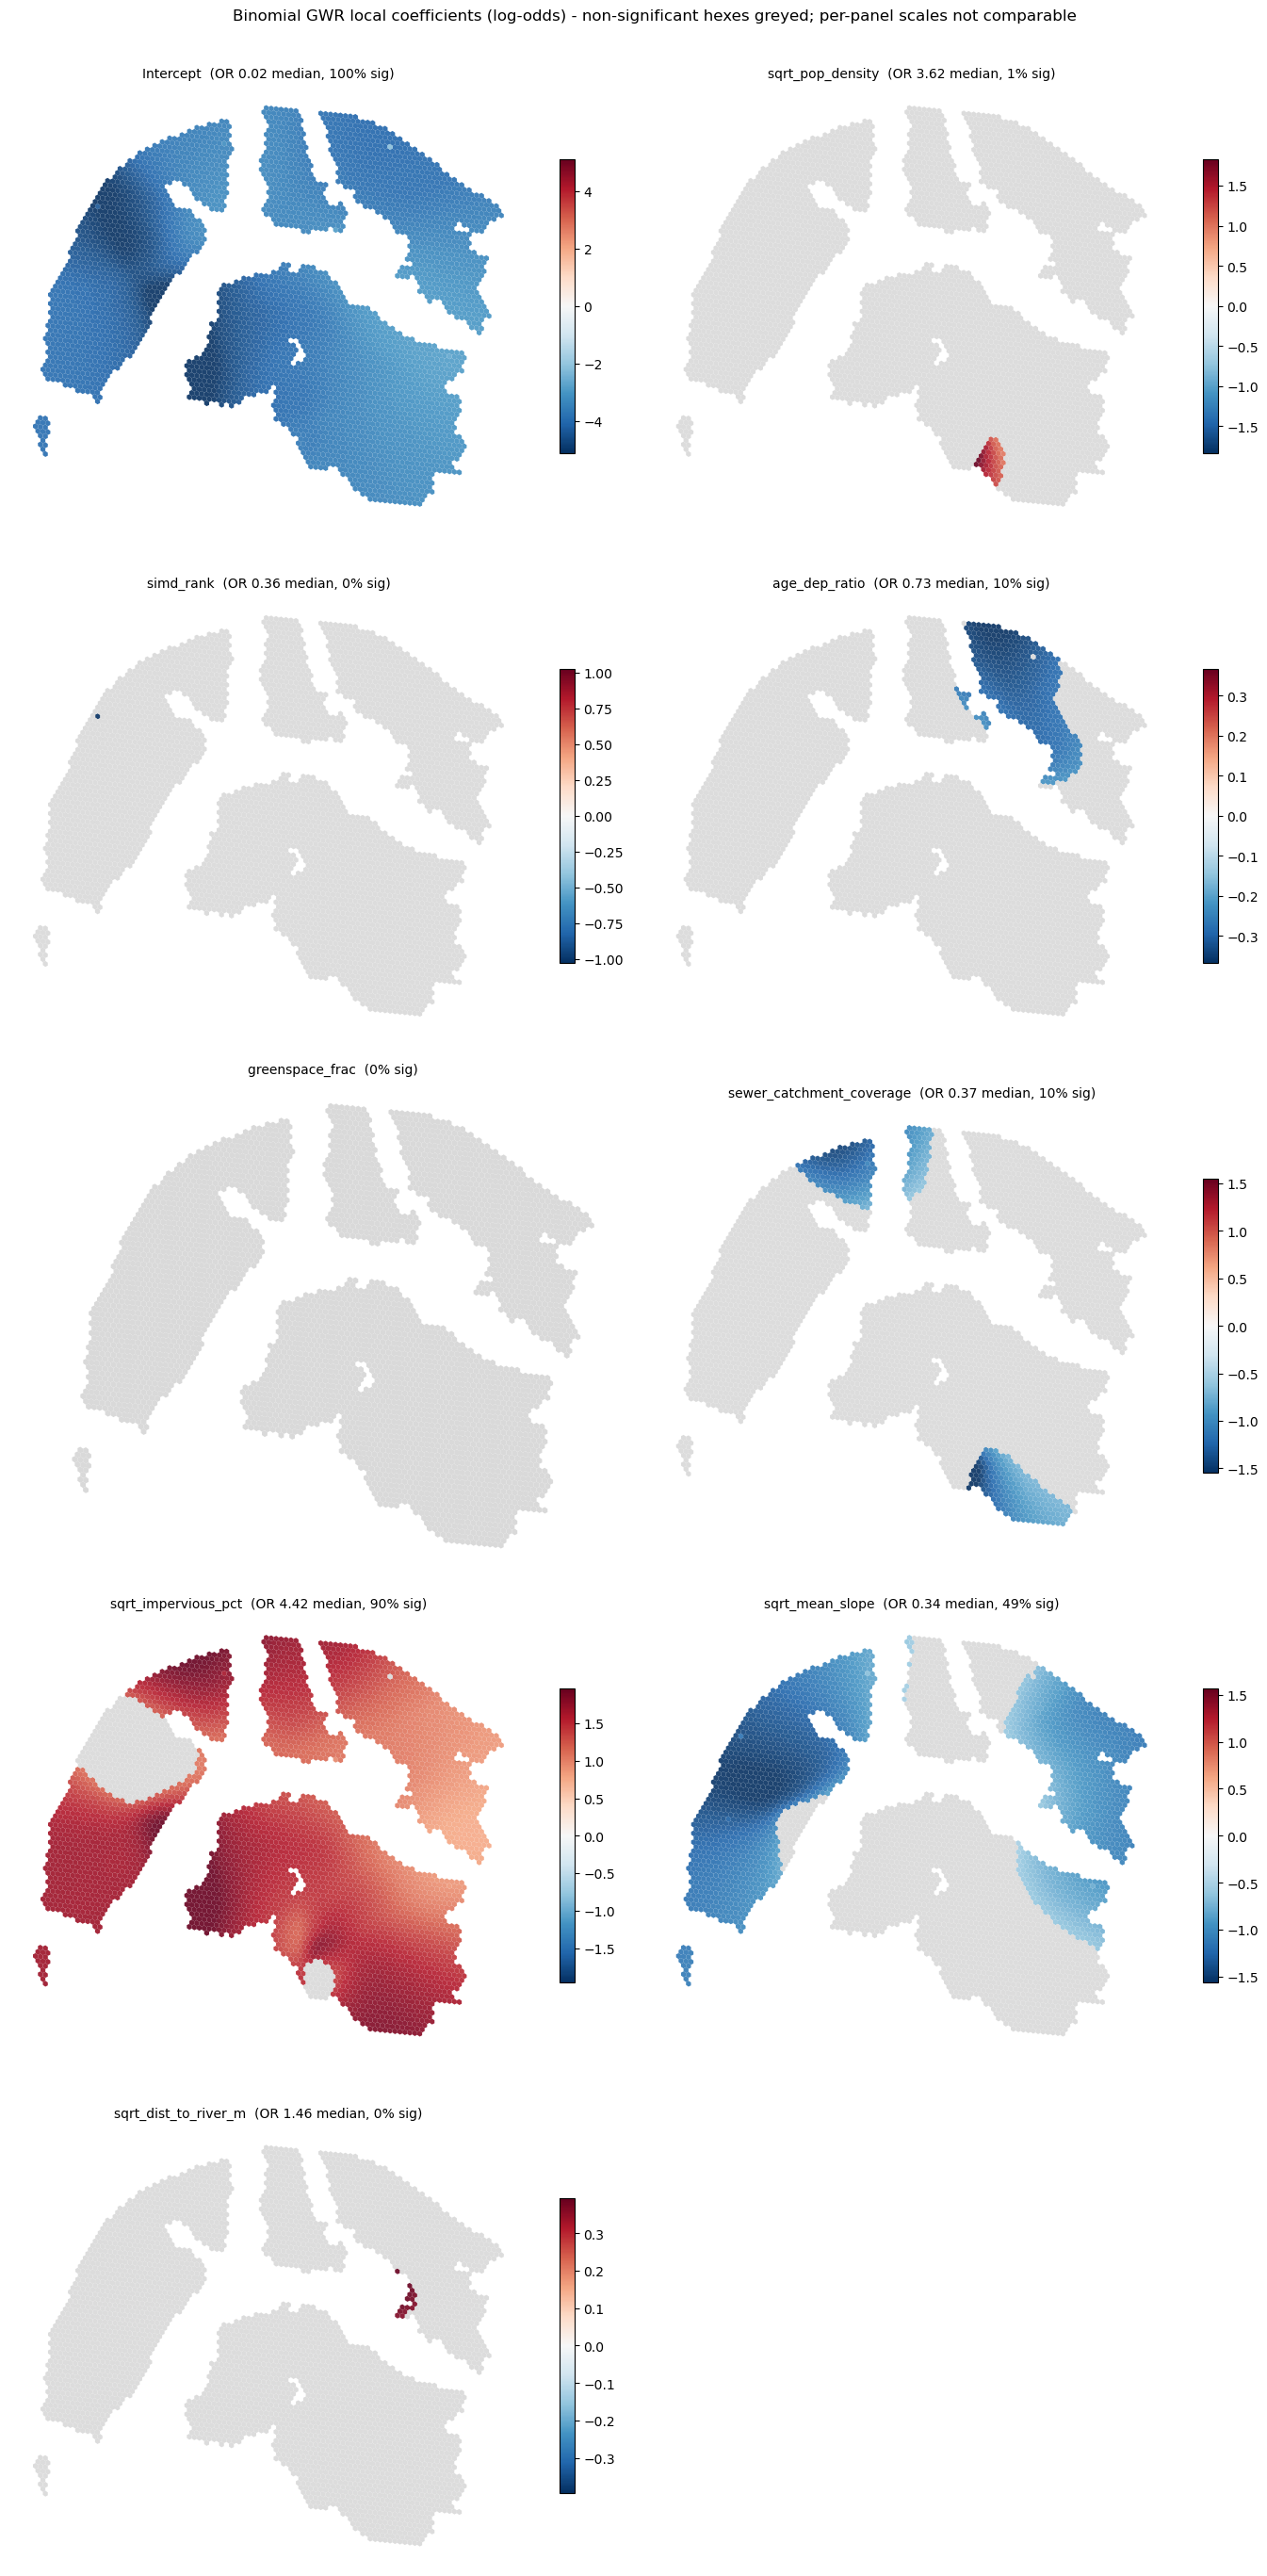

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


MODEL   = gwr_results          # fitted binomial GWR object
N_COLS  = 2
PCTL    = 98
BASEMAP = False
CMAP    = "RdBu_r"
OUTFILE = "binomial_gwr_masked_grid.png"

names  = ["Intercept"] + list(PREDICTORS_FINAL)
params = np.asarray(MODEL.params, dtype=float)
assert params.shape[1] == len(names), \
    f"{params.shape[1]} param cols vs {len(names)} names"
n_obs, k = params.shape

# Significance: corrected critical t 
tvals = np.asarray(MODEL.tvalues, dtype=float)
try:
    crit = np.asarray(MODEL.critical_tval()).ravel()
    if crit.size == 1:
        crit = np.repeat(crit, k)
    elif crit.size != k:
        raise ValueError(f"critical_tval size {crit.size} != {k}")
    print("corrected critical t:", np.round(crit, 3))
except Exception as e:
    crit = np.full(k, 1.96)
    print(f"[note] critical_tval() unusable ({e}); using |t|>=1.96")
sig = np.abs(tvals) >= crit[np.newaxis, :]

gplot = gdf.to_crs(epsg=3857) if BASEMAP else gdf
if BASEMAP:
    import contextily as ctx

# Plot
n_rows = int(np.ceil(k / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(7 * N_COLS, 5.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for i, name in enumerate(names):
    ax = axes[i]
    beta  = params[:, i].astype(float).copy()
    sig_i = sig[:, i]
    pct   = 100 * sig_i.mean()

    plot_vals = beta.copy()
    plot_vals[~sig_i] = np.nan            # non-significant -> grey

    ref = beta[sig_i]; ref = ref[np.isfinite(ref)]
    g = gplot.copy()
    g["_b"] = plot_vals

    if ref.size == 0:
        # significant NOWHERE: render a full all-grey panel (uniform grid)
        g.plot(color="#d9d9d9", ax=ax, edgecolor="none")
        if BASEMAP:
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution="")
        ax.set_axis_off()
        ax.set_title(f"{name}  (0% sig)", fontsize=10)
        continue

    vmax = max(np.percentile(np.abs(ref), PCTL), 1e-9)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    g.plot(column="_b", cmap=CMAP, norm=norm, ax=ax,
           edgecolor="none", alpha=0.9,
           legend=True, legend_kwds={"shrink": 0.6},
           missing_kwds={"color": "#d9d9d9", "label": "not sig."})
    if BASEMAP:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution="")
    ax.set_axis_off()

    sig_beta = beta[sig_i]; sig_beta = sig_beta[np.isfinite(sig_beta)]
    med_or = np.exp(np.median(sig_beta)) if sig_beta.size else np.nan
    ax.set_title(f"{name}  (OR {med_or:.2f} median, {pct:.0f}% sig)", fontsize=10)

# hide any leftover empty axes (only if k is odd)
for j in range(k, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Binomial GWR local coefficients (log-odds) - non-significant "
             "hexes greyed; per-panel scales not comparable", fontsize=12, y=1.002)
plt.tight_layout()
fig.savefig(OUTFILE, dpi=200, bbox_inches="tight")
print(f"Saved: {OUTFILE}")

print("\nLocal significance by variable:")
for i, name in enumerate(names):
    print(f"  {name:<28} {100*sig[:, i].mean():5.1f}% sig")
plt.show()

# Option B binomial GWR coefficient maps WITH significance masking.
Only the first 4 predictors (Intercept + first 3 covariates), plotted larger.

corrected critical t: [2.641 2.641 2.641 2.641 2.641 2.641 2.641 2.641 2.641]
Saved: binomial_gwr_optionB_masked_first4.png

Local significance by variable (corrected critical t):
  Intercept                    100.0% sig
  sqrt_pop_density               1.0% sig
  simd_rank                      0.0% sig
  age_dep_ratio                 10.0% sig


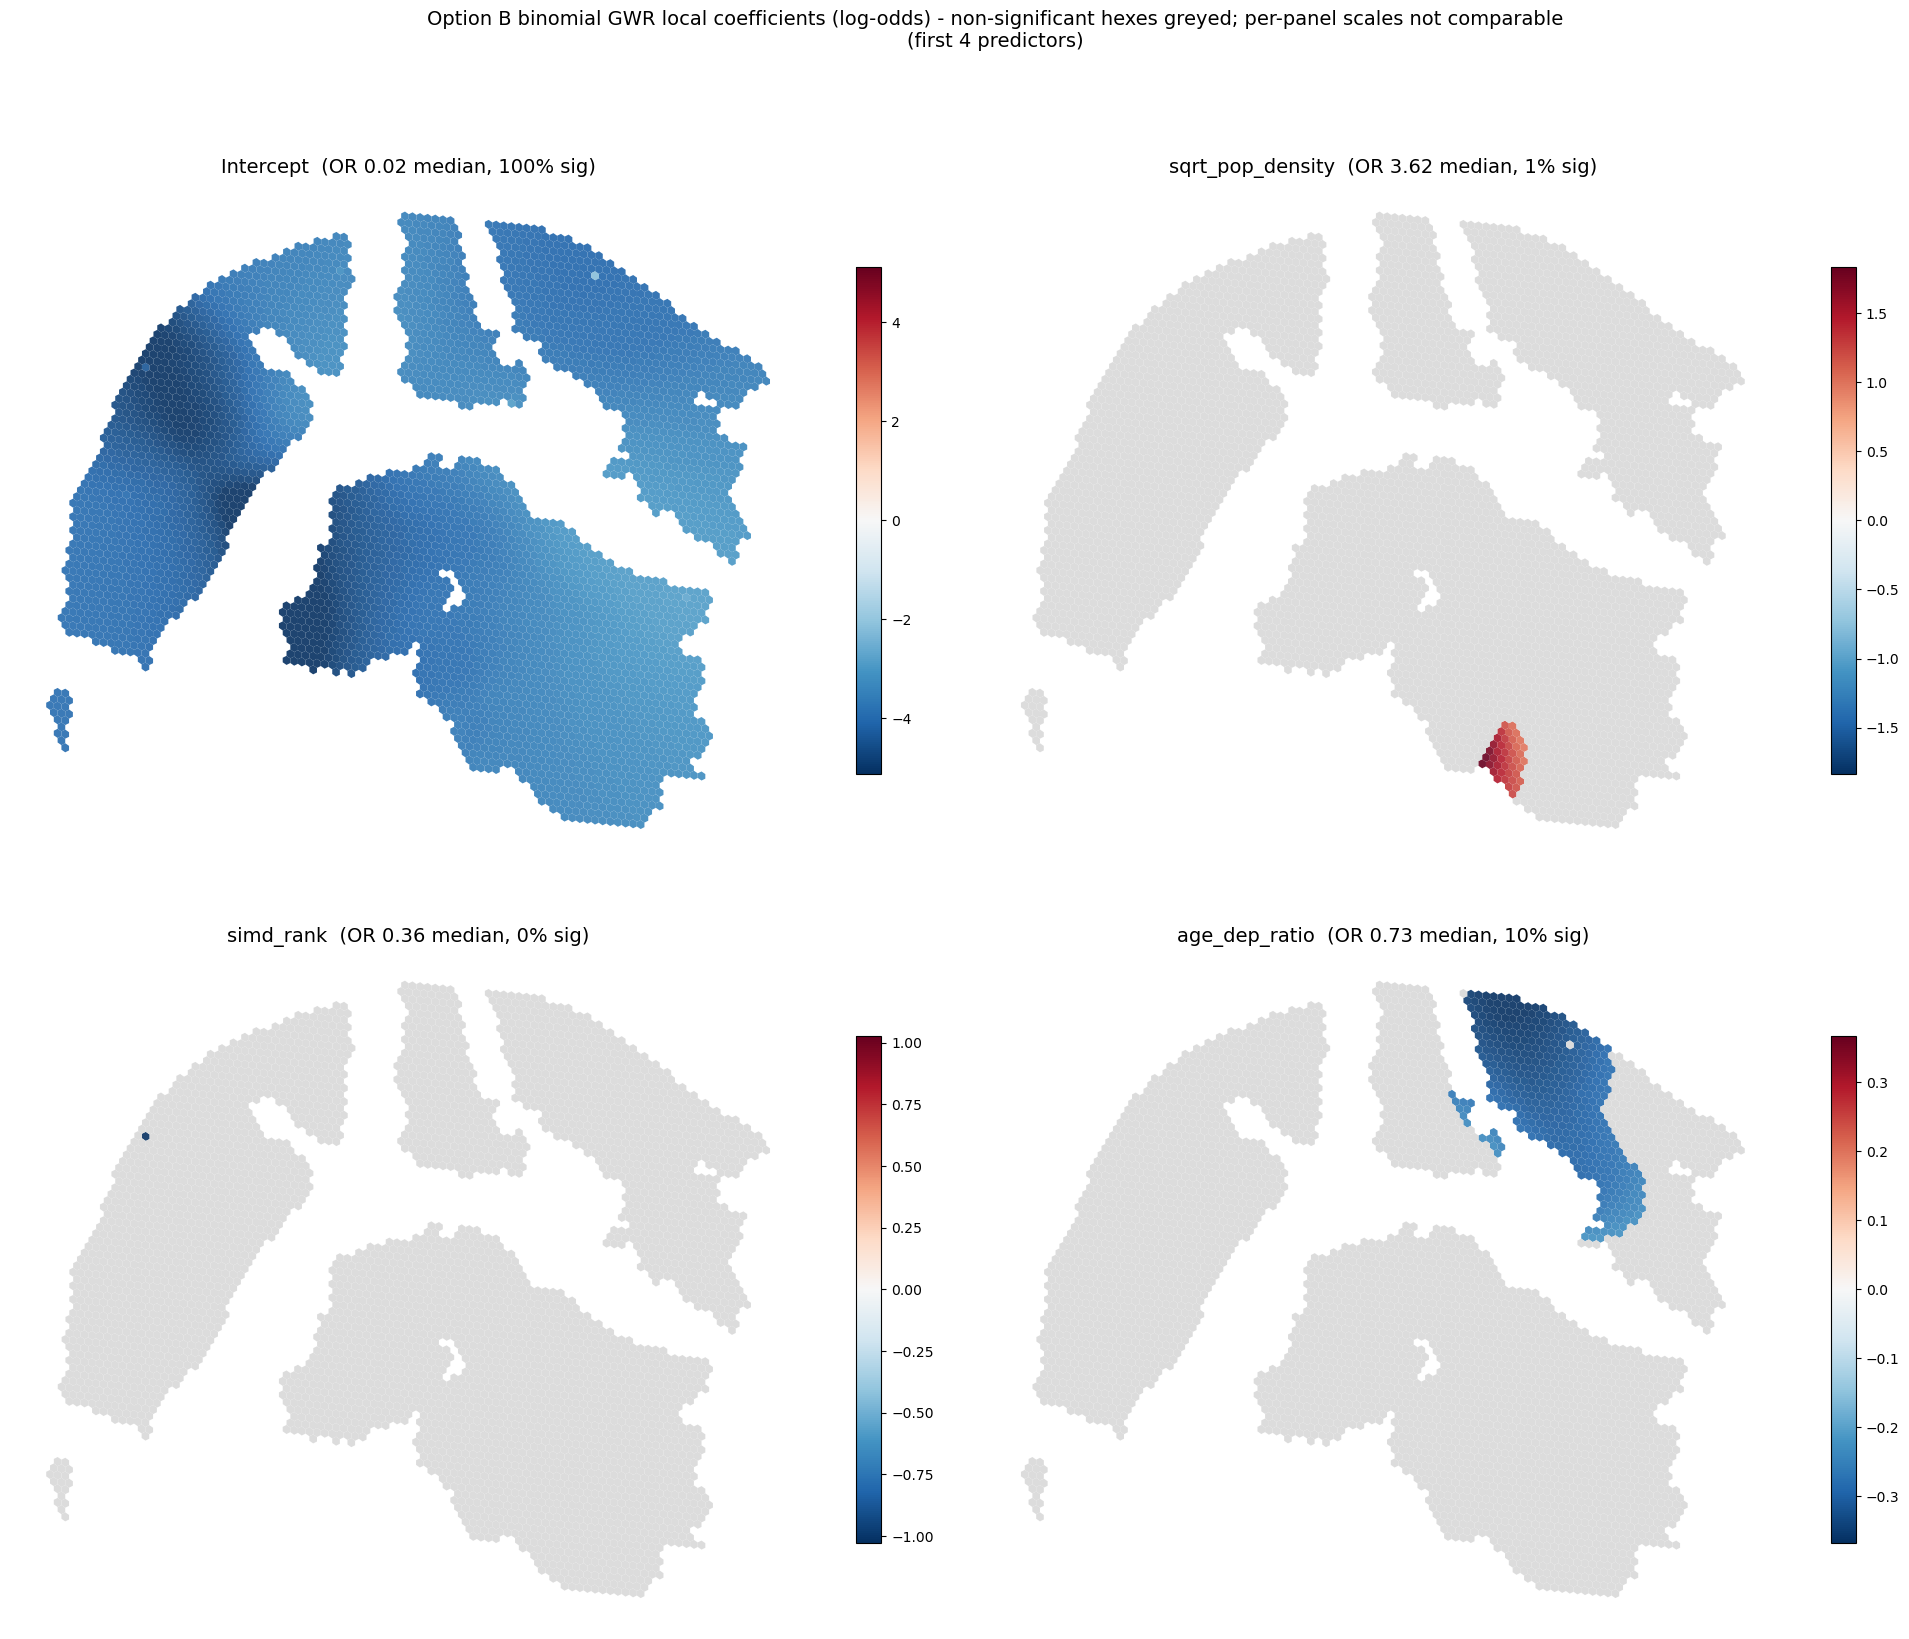

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


MODEL     = gwr_results        # fitted binomial GWR object
N_COLS    = 2
PCTL      = 98                 # per-panel colour clip (on significant cells)
BASEMAP   = False              # True -> light CartoDB Positron under each panel
CMAP      = "RdBu_r"           # red = positive log-odds, blue = negative
N_PANELS  = 4                  # <-- only plot the first N predictors
FIGSIZE_W = 10                 # per-column width (was 7)
FIGSIZE_H = 8.5                # per-row height (was 5.5)

names_all = ["Intercept"] + list(PREDICTORS_FINAL)
params_all = np.asarray(MODEL.params, dtype=float)
assert params_all.shape[1] == len(names_all), \
    f"{params_all.shape[1]} param cols vs {len(names_all)} names"
n_obs, k_all = params_all.shape

# Restrict to first N_PANELS predictors 
k = min(N_PANELS, k_all)
names = names_all[:k]
params = params_all[:, :k]

# Significance: corrected critical t 
tvals_all = np.asarray(MODEL.tvalues, dtype=float)
try:
    crit_all = np.asarray(MODEL.critical_tval()).ravel()
    if crit_all.size == 1:                   # GWR returns a single corrected value
        crit_all = np.repeat(crit_all, k_all)
    elif crit_all.size != k_all:
        raise ValueError(f"critical_tval size {crit_all.size} != {k_all}")
    print("corrected critical t:", np.round(crit_all, 3))
except Exception as e:
    crit_all = np.full(k_all, 1.96)
    print(f"[note] critical_tval() unusable ({e}); using |t|>=1.96")

tvals = tvals_all[:, :k]
crit = crit_all[:k]
sig = np.abs(tvals) >= crit[np.newaxis, :]   # (n, k) boolean

# Reproject once if using a basemap
gplot = gdf.to_crs(epsg=3857) if BASEMAP else gdf
if BASEMAP:
    import contextily as ctx

# PLot 
n_rows = int(np.ceil(k / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS,
                          figsize=(FIGSIZE_W * N_COLS, FIGSIZE_H * n_rows))
axes = np.atleast_1d(axes).ravel()

for i, name in enumerate(names):
    ax = axes[i]
    beta  = params[:, i].astype(float).copy()
    sig_i = sig[:, i]

    # mask: non-significant -> NaN (renders grey via missing_kwds)
    plot_vals = beta.copy()
    plot_vals[~sig_i] = np.nan

    # colour scale from SIGNIFICANT, FINITE coefficients only
    ref = beta[sig_i]
    ref = ref[np.isfinite(ref)]
    if ref.size == 0:
        ax.set_title(f"{name}\n(0% locally significant)", fontsize=12)
        ax.set_axis_off()
        continue
    vmax = np.percentile(np.abs(ref), PCTL)
    vmax = max(vmax, 1e-9)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    g = gplot.copy()
    g["_b"] = plot_vals
    g.plot(column="_b", cmap=CMAP, norm=norm, ax=ax,
           edgecolor="none", alpha=0.9,
           legend=True, legend_kwds={"shrink": 0.6},
           missing_kwds={"color": "#d9d9d9", "label": "not sig."})

    if BASEMAP:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution="")

    ax.set_axis_off()

    # Title: median OR over significant cells + % significant
    sig_beta = beta[sig_i]; sig_beta = sig_beta[np.isfinite(sig_beta)]
    med_or = np.exp(np.median(sig_beta)) if sig_beta.size else np.nan
    pct = 100 * sig_i.mean()
    ax.set_title(f"{name}  (OR {med_or:.2f} median, {pct:.0f}% sig)", fontsize=14)

for j in range(k, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Option B binomial GWR local coefficients (log-odds) - "
             "non-significant hexes greyed; per-panel scales not comparable\n"
             f"(first {k} predictors)",
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig("binomial_gwr_optionB_masked_first4.png", dpi=200, bbox_inches="tight")
print("Saved: binomial_gwr_optionB_masked_first4.png")


print("\nLocal significance by variable (corrected critical t):")
for i, name in enumerate(names):
    print(f"  {name:<28} {100*sig[:, i].mean():5.1f}% sig")
plt.show()

# the last 4 predictors

corrected critical t: [2.641 2.641 2.641 2.641 2.641 2.641 2.641 2.641 2.641]
Saved: binomial_gwr_optionB_masked_next4.png

Local significance by variable (corrected critical t):
  greenspace_frac                0.0% sig
  sewer_catchment_coverage      10.1% sig
  sqrt_impervious_pct           89.8% sig
  sqrt_mean_slope               48.7% sig


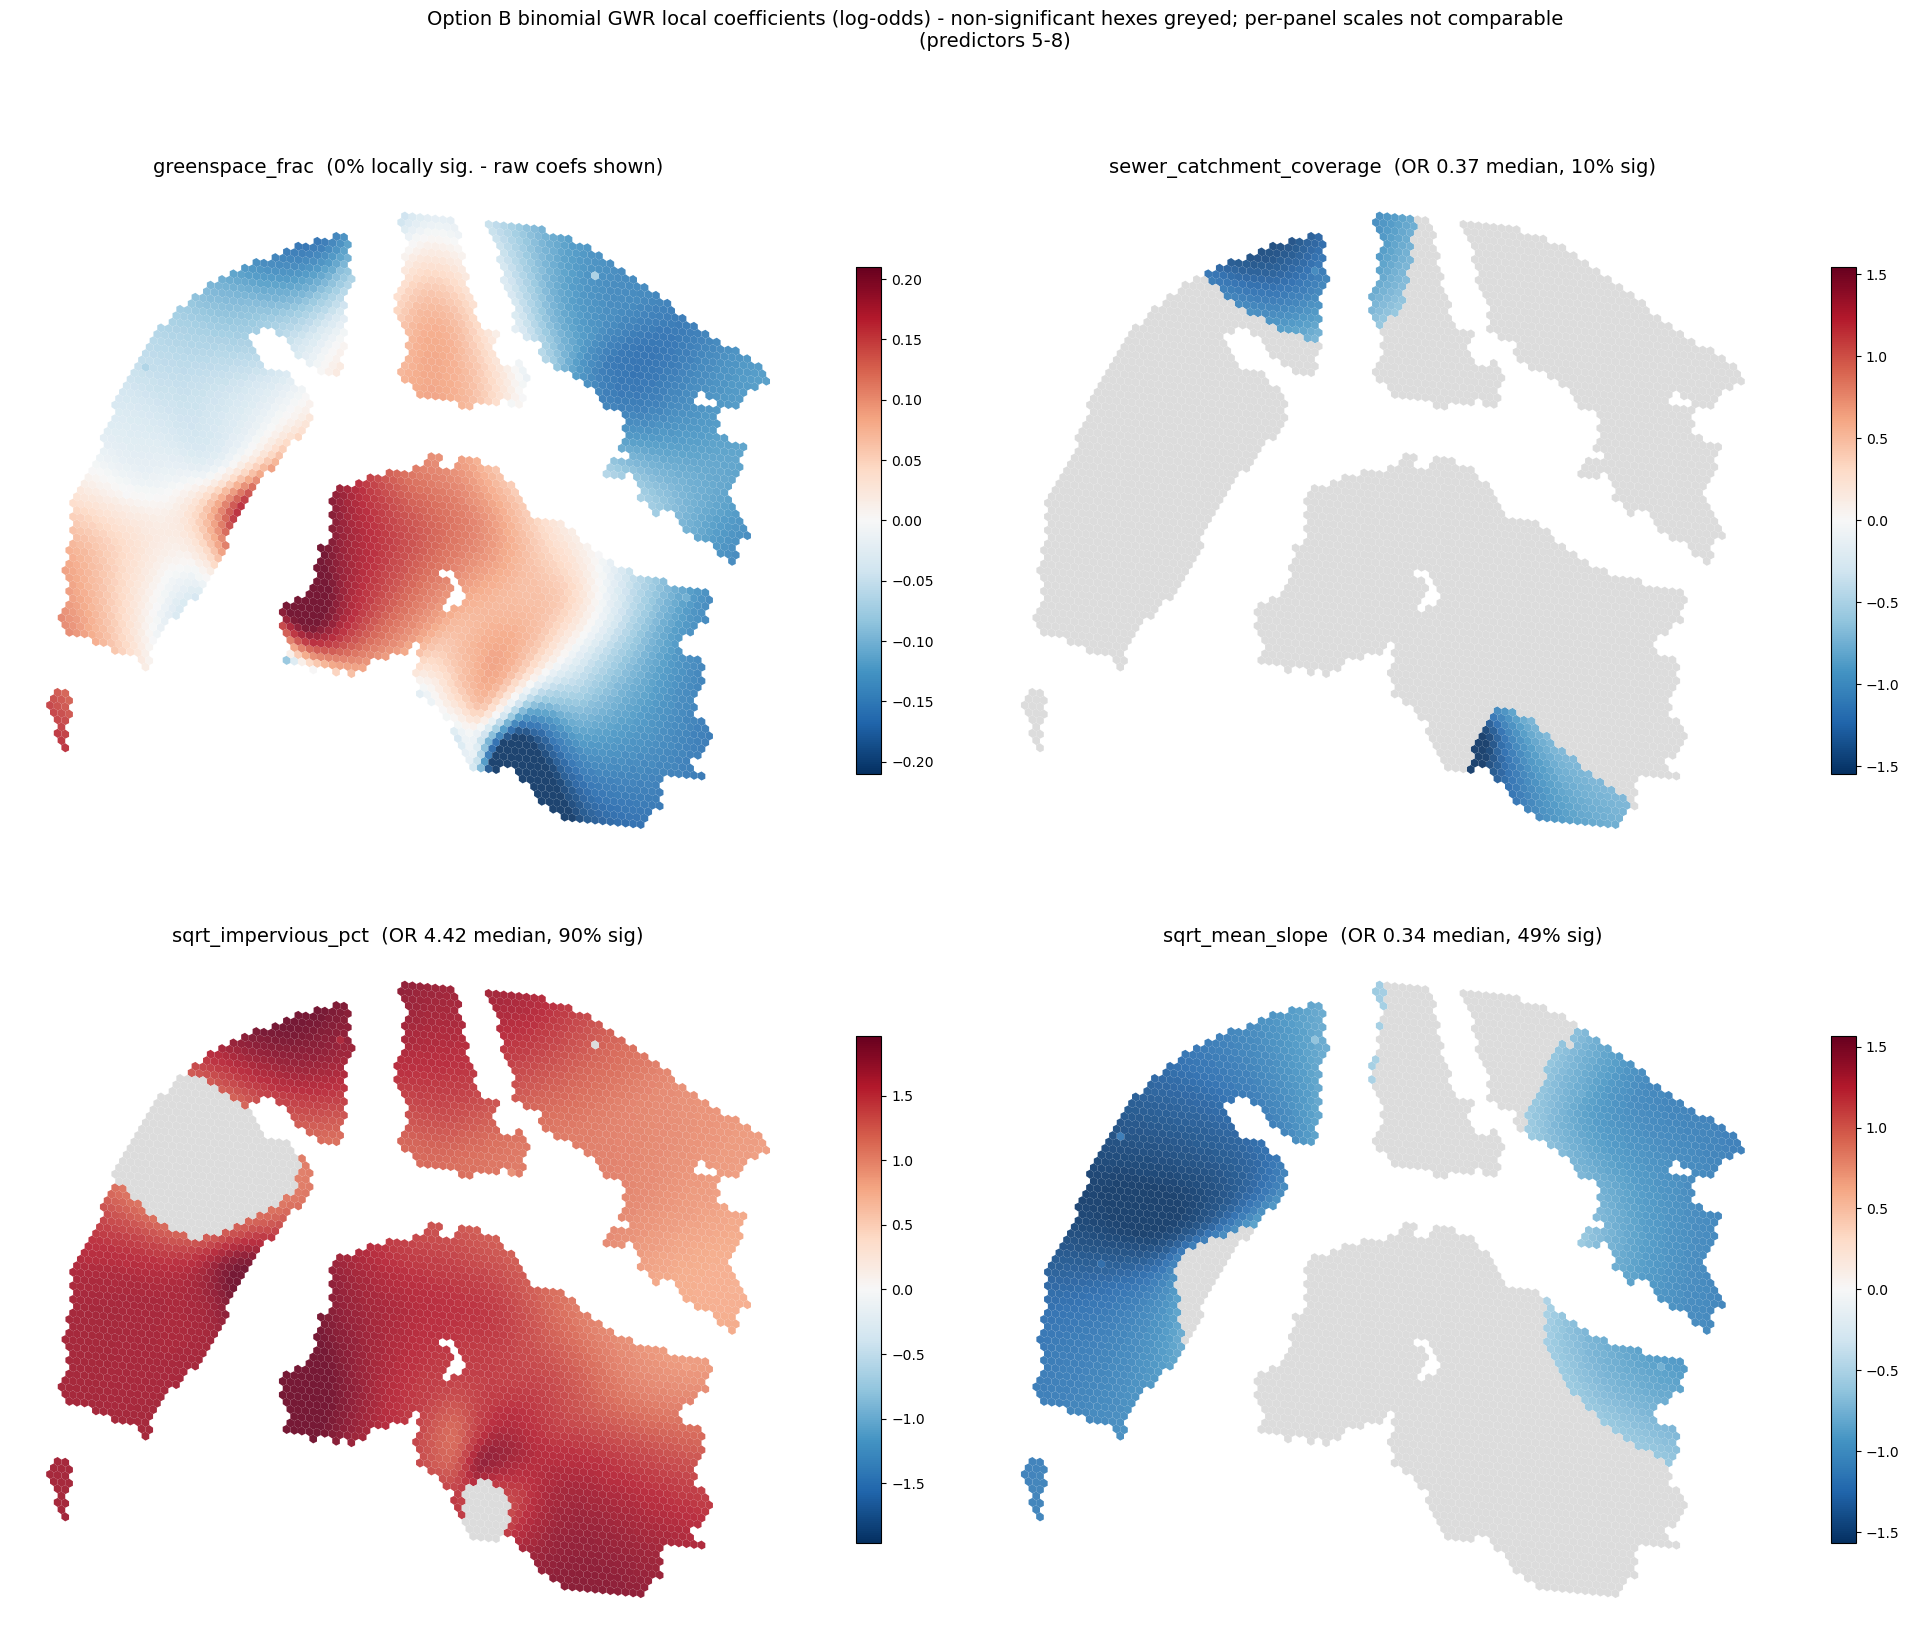

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


MODEL   = gwr_results         
N_COLS  = 2
PCTL    = 98                   # per-panel colour clip
BASEMAP = False                # True -> light CartoDB Positron under each panel
CMAP    = "RdBu_r"             # red = positive log-odds, blue = negative
FIGSIZE_W = 10                 # per-column width
FIGSIZE_H = 8.5                # per-row height

names_all = ["Intercept"] + list(PREDICTORS_FINAL)
params_all = np.asarray(MODEL.params, dtype=float)
assert params_all.shape[1] == len(names_all), \
    f"{params_all.shape[1]} param cols vs {len(names_all)} names"
n_obs, k_all = params_all.shape

tvals_all = np.asarray(MODEL.tvalues, dtype=float)
try:
    crit_all = np.asarray(MODEL.critical_tval()).ravel()
    if crit_all.size == 1:
        crit_all = np.repeat(crit_all, k_all)
    elif crit_all.size != k_all:
        raise ValueError(f"critical_tval size {crit_all.size} != {k_all}")
    print("corrected critical t:", np.round(crit_all, 3))
except Exception as e:
    crit_all = np.full(k_all, 1.96)
    print(f"[note] critical_tval() unusable ({e}); using |t|>=1.96")

sig_all = np.abs(tvals_all) >= crit_all[np.newaxis, :]   # (n, k_all) boolean

gplot = gdf.to_crs(epsg=3857) if BASEMAP else gdf
if BASEMAP:
    import contextily as ctx


def plot_gwr_panels(start_idx, n_panels, out_png):
    """Plot predictors [start_idx : start_idx+n_panels] with significance
    masking, always showing a map (raw fallback when 0% significant)."""
    end_idx = min(start_idx + n_panels, k_all)
    names = names_all[start_idx:end_idx]
    params = params_all[:, start_idx:end_idx]
    sig = sig_all[:, start_idx:end_idx]
    k = len(names)
    assert k > 0, f"start_idx={start_idx} is beyond the available {k_all} predictors"

    n_rows = int(np.ceil(k / N_COLS))
    fig, axes = plt.subplots(n_rows, N_COLS,
                              figsize=(FIGSIZE_W * N_COLS, FIGSIZE_H * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for i, name in enumerate(names):
        ax = axes[i]
        beta  = params[:, i].astype(float).copy()
        sig_i = sig[:, i]
        finite = np.isfinite(beta)

        sig_ref = beta[sig_i & finite]

        if sig_ref.size > 0:
            # normal path: mask non-significant hexes to grey
            plot_vals = beta.copy()
            plot_vals[~sig_i] = np.nan
            vmax = max(np.percentile(np.abs(sig_ref), PCTL), 1e-9)
            legend_label = "not sig."
            med_or = np.exp(np.median(sig_ref))
            pct = 100 * sig_i.mean()
            title = f"{name}  (OR {med_or:.2f} median, {pct:.0f}% sig)"
        else:
            #  0% significant -> show RAW unmasked coefficients
            plot_vals = beta.copy()
            raw_ref = beta[finite]
            vmax = max(np.percentile(np.abs(raw_ref), PCTL), 1e-9) if raw_ref.size else 1e-9
            legend_label = "no data"
            title = f"{name}  (0% locally sig. - raw coefs shown)"

        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        g = gplot.copy()
        g["_b"] = plot_vals
        g.plot(column="_b", cmap=CMAP, norm=norm, ax=ax,
               edgecolor="none", alpha=0.9,
               legend=True, legend_kwds={"shrink": 0.6},
               missing_kwds={"color": "#d9d9d9", "label": legend_label})

        if BASEMAP:
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution="")

        ax.set_axis_off()
        ax.set_title(title, fontsize=14)

    for j in range(k, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Option B binomial GWR local coefficients (log-odds) - "
                 "non-significant hexes greyed; per-panel scales not comparable\n"
                 f"(predictors {start_idx+1}-{end_idx})",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {out_png}")

    print("\nLocal significance by variable (corrected critical t):")
    for i, name in enumerate(names):
        print(f"  {name:<28} {100*sig[:, i].mean():5.1f}% sig")
    plt.show()


# Run for the next 4 predictors (indices 4-7) 
plot_gwr_panels(start_idx=4, n_panels=4, out_png="binomial_gwr_optionB_masked_next4.png")



# Binomial MGWR fit + diagnostics (Option B: flooded-only median target).

In [ ]:
import json
import warnings
import numpy as np
import geopandas as gpd

from mgwr.gwr import MGWR
from mgwr.sel_bw import Sel_BW
from spglm.family import Binomial
from libpysal.weights import Queen
from esda.moran import Moran
from scipy.linalg import LinAlgWarning


RESPONSE   = "s1"
CLEAN_PATH = f"hex_binary_{RESPONSE}.gpkg"
PRED_JSON  = f"hex_binary_{RESPONSE}_predictors.json"
Y_BINARY   = f"{RESPONSE}_flooded"
# Per-covariate bandwidth floor for the multiscale search. The GWR compromise
# was ~1200; MGWR will let some covariates go finer. This floor stops any single
# covariate's bandwidth collapsing so small that local windows separate.
# Balanced (~40% positive) data tolerates a smallish floor; raise if I see
# non-finite coefficients below.
BW_MIN     = 100
MULTI_TOL  = 1e-5          # backfitting convergence tolerance
MULTI_MAXIT = 200          # backfitting iteration cap
CACHE      = True


gdf = gpd.read_file(CLEAN_PATH)
gdf = gdf.reset_index(drop=True)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs("EPSG:3035")

PREDICTORS_FINAL = json.load(open(PRED_JSON))
Z_COLS = [f"{c}_z" for c in PREDICTORS_FINAL]
missing = [c for c in Z_COLS + [Y_BINARY] if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing columns in {CLEAN_PATH}: {missing}")

X = gdf[Z_COLS].to_numpy(dtype=float)
y = gdf[Y_BINARY].to_numpy().reshape(-1, 1).astype(float)
assert set(np.unique(y.ravel())) <= {0.0, 1.0}, "y must be binary 0/1"
if np.isnan(X).any() or np.isnan(y).any():
    raise ValueError("NaN in X or y.")

if gdf.geometry.is_empty.any() or gdf.geometry.isna().any():
    raise ValueError("Empty/null geometry.")
cent = gdf.geometry.centroid
coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
if np.isnan(coords).any():
    raise ValueError("NaN in coords.")

NAME_X = ["Intercept"] + list(PREDICTORS_FINAL)

n_pos = int(y.sum()); n = len(y)
print(f"Sample: {n:,} hexes | flooded {n_pos:,} ({100*n_pos/n:.1f}% positive)")
print(f"Predictors ({len(PREDICTORS_FINAL)}): {PREDICTORS_FINAL}")
print(f"X {X.shape}  y {y.shape}  coords {coords.shape}\n")

# Multiscale bandwidth search (binomial)
print("Searching per-covariate bandwidths (binomial MGWR)... slow, be patient.")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    sel = Sel_BW(coords, y, X, family=Binomial(), multi=True,
                 kernel="bisquare", constant=True)
    mgwr_bw = sel.search(criterion="AICc",
                         multi_bw_min=[BW_MIN],   # floor applied to all covariates
                         tol_multi=MULTI_TOL,
                         max_iter_multi=MULTI_MAXIT)
np.seterr(**old)
print("Selected bandwidths (per covariate):")
for nm, b in zip(NAME_X, np.asarray(mgwr_bw).ravel()):
    print(f"    {nm:<28} {b:>8.0f}")

# Fit binomial MGWR 
print("\nFitting binomial MGWR...")
old = np.seterr(all="ignore")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    model = MGWR(coords, y, X, selector=sel, family=Binomial(),
                 constant=True, name_x=NAME_X)
    mgwr_results = model.fit()
np.seterr(**old)

# Verify it is ACTUALLY binomial 
fam = getattr(getattr(model, "family", None), "__class__", None)
fam_name = fam.__name__ if fam is not None else "unknown"
if fam_name != "Binomial":
    print(f"\n[ABORT] Fitted family reports '{fam_name}', not Binomial. "
          "This mgwr version does not support binomial MGWR. "
          "Fall back to Option B binomial GWR with the residual-autocorrelation "
          "limitation; do NOT report this as a binomial MGWR result.")
    raise SystemExit(1)

params = np.asarray(mgwr_results.params, dtype=float)
if not np.isfinite(params).all():
    n_bad = int((~np.isfinite(params)).any(axis=1).sum())
    print(f"[warning] {n_bad} hexes have non-finite local coefficients "
          "(local separation) - raise BW_MIN and refit.")

print("\n" + "=" * 60)
try:
    mgwr_results.summary()
except Exception as e:
    print(f"[note] summary() unavailable for this fit ({e}); using manual report.")
print("=" * 60)

# Diagnostics 
print(f"\n  AICc : {mgwr_results.aicc:.1f}")
try:
    print(f"  ENP  (per covariate): "
          f"{np.round(np.asarray(mgwr_results.ENP_j).ravel(), 1)}")
except Exception:
    pass

print("\n  Local coefficient ranges (log-odds -> odds ratios):")
for j, nm in enumerate(NAME_X):
    col = params[:, j]; col = col[np.isfinite(col)]
    if col.size:
        print(f"    {nm:<28} [{col.min():+.3f}, {col.max():+.3f}]  "
              f"OR [{np.exp(col.min()):.2f}, {np.exp(col.max()):.2f}]")

# Residual Moran's I 
print("\nResidual Moran's I...")
try:
    resid = np.asarray(mgwr_results.resid_response, dtype=float).ravel()
except AttributeError:
    yhat = np.asarray(mgwr_results.predy, dtype=float).ravel()
    resid = y.ravel() - yhat

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = "r"
mi = Moran(resid, w, permutations=999)
print(f"  Moran's I {mi.I:.4f} | E[I] {mi.EI:.4f} | p {mi.p_sim:.4f}")
if mi.p_sim < 0.05:
    print("  -> residuals STILL autocorrelated: even multiscale did not fully "
          "absorb spatial dependence. Report GWR/MGWR with this as a limitation.")
else:
    print("  -> residuals consistent with spatial randomness: MGWR resolved the "
          "autocorrelation that single-bandwidth GWR left. Strong result.")

# Cache (results + bandwidths; NOT the selector)
if CACHE:
    try:
        import joblib
        joblib.dump(mgwr_results, f"binomial_mgwr_results_{RESPONSE}.pkl")
        joblib.dump(np.asarray(mgwr_bw), f"binomial_mgwr_bw_{RESPONSE}.pkl")
        print(f"\nCached: binomial_mgwr_results_{RESPONSE}.pkl + bandwidths.")
    except Exception as e:
        print(f"[note] pickle failed ({e}); saving arrays to npz.")
        np.savez(f"binomial_mgwr_{RESPONSE}.npz",
                 params=params, tvals=np.asarray(mgwr_results.tvalues),
                 bw=np.asarray(mgwr_bw), aicc=float(mgwr_results.aicc),
                 names=np.array(NAME_X))
        print(f"Cached: binomial_mgwr_{RESPONSE}.npz")

print("\nDone. `mgwr_results` holds the fit; coefficients are LOG-ODDS "
      "(exp() for odds ratios). Feed into the visualiser with BINOMIAL=True.")

In [44]:
import inspect
print(inspect.signature(MGWR.__init__))

(self, coords, y, X, selector, sigma2_v1=True, kernel='bisquare', fixed=False, constant=True, spherical=False, hat_matrix=False, name_x=None, n_jobs=1)


In [40]:
mgwr_results.summary()

NameError: name 'mgwr_results' is not defined